In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df_train = pd.read_parquet("data/processed/train.parquet")
df_test = pd.read_parquet("data/processed/test.parquet")


X_train = df_train.drop(columns=["target"]).copy()
y_train = df_train["target"].copy()

cols_free_text = ["emp_title", "desc", "title", "url", "zip_code"]
cols_joint = df_train.columns[df_train.columns.str.contains("_joint")].tolist()
cols_sec_app = df_train.columns[df_train.columns.str.startswith("sec_app_")].tolist()
cols_vintage_limited = [
    "open_acc_6m",
    "open_act_il",
    "open_il_12m",
    "open_il_24m",
    "mths_since_rcnt_il",
    "total_bal_il",
    "il_util",
    "open_rv_12m",
    "open_rv_24m",
    "max_bal_bc",
    "all_util",
    "inq_fi",
    "total_cu_tl",
    "inq_last_12m",
]
cols_to_drop = [
    *cols_free_text,
    *cols_joint,
    *cols_sec_app,
    *cols_vintage_limited,
    "policy_code",
    "target",
    "earliest_cr_line",  # This column is dropped because of SMOTE
]


numeric_features = (
    df_train.drop(columns=cols_to_drop)
    .select_dtypes(include=["number"])
    .columns.tolist()
)
print(f"Numeric features: {len(numeric_features)}")

categorical_features = (
    df_train.drop(columns=cols_to_drop)
    .select_dtypes(include=["str", "category"])
    .columns.tolist()
)
print(f"Categorical features: {len(categorical_features)}")

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

max_iterations = 1000
tscv = TimeSeriesSplit(n_splits=3)

balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=max_iterations,
                class_weight="balanced",
            ),
        ),
    ],
)


cv_results = cross_validate(
    balanced_pipeline,
    X_train,
    y_train,
    cv=tscv,
    scoring=["roc_auc", "average_precision"],
    return_train_score=True,
)
print("Cross-validation results for Balanced Pipeline:")
for metric in ["roc_auc", "average_precision"]:
    print(
        f"{metric}: {cv_results['test_' + metric].mean():.4f} ± {cv_results['test_' + metric].std():.4f}"
    )


Numeric features: 61
Categorical features: 12
Cross-validation results for Balanced Pipeline:
roc_auc: 0.7266 ± 0.0091
average_precision: 0.4072 ± 0.0243


In [2]:
smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "classifier",
            LogisticRegression(
                max_iter=max_iterations,
            ),
        ),
    ],
)

cv_results = cross_validate(
    smote_pipeline,
    X_train,
    y_train,
    cv=tscv,
    scoring=["roc_auc", "average_precision"],
    return_train_score=True,
)
print("Cross-validation results for SMOTE pipeline:")
for metric in ["roc_auc", "average_precision"]:
    print(
        f"{metric}: {cv_results['test_' + metric].mean():.4f} ± {cv_results['test_' + metric].std():.4f}"
    )

Cross-validation results for SMOTE pipeline:
roc_auc: 0.7205 ± 0.0096
average_precision: 0.4011 ± 0.0257


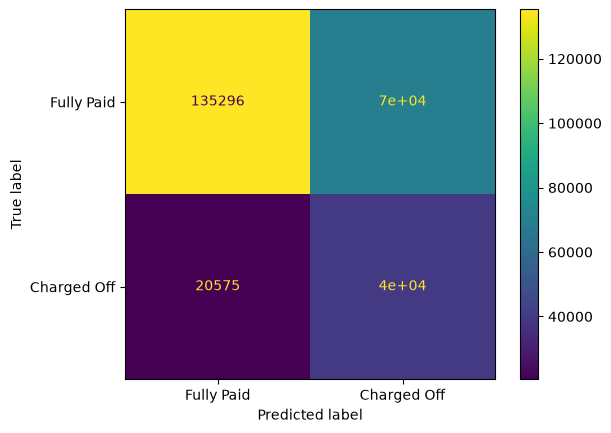

In [3]:
# For confusion matrix and classification report, we can use the last split of the TimeSeriesSplit
train_idx, test_idx = list(tscv.split(X_train))[-1]

last_X_train = X_train.iloc[train_idx]
last_y_train = y_train.iloc[train_idx]

last_X_val = X_train.iloc[test_idx]
last_y_val = y_train.iloc[test_idx]

balanced_pipeline.fit(last_X_train, last_y_train)

y_pred = balanced_pipeline.predict(last_X_val)

cm = confusion_matrix(last_y_val, y_pred)

ConfusionMatrixDisplay.from_predictions(
    last_y_val, y_pred, display_labels=["Fully Paid", "Charged Off"]
)


# Understanding Week 5

## Data Clean-up and Features

To embed the categorical columns, we chose to drop free columns that give value to the model like free text columns. The `*_joint` and `sec_app_*` column because of ?. The model had some issue with time columns, so they where dropped as well.

We ended up with 61 numeric features, and 12 categorical.

## The Data Pipeline

### Transformer

The numeric transformer filled all null values with the median of the column. Then it standardized so every numeric feature is on a comparable scale.
The categorical transformer filled the null values with the most frequent value. It then used OneHotEncoder

###
